# Cadastral Building Floors Analysis

This notebook calculates statistics regarding the volume of surrounding structures for each street in our dataset explicitly relying on data provided by **Cadastre**.

The main pipeline performs the following steps:
1. Loads cadastral building parts and the main noise streets layer.
2. Cleans the target metric `numberOfFloorsAboveGround`.
3. Buffers out paths iteratively (50m, 100m) and matches intersecting structures.
4. Aggregates and merges these derived values down to the explicit standard identifiers (`fid`, `TRAM`).
5. Exports the compiled features as an ML-ready CSV in the processed data directory.

In [4]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np

## 1. Load Geospatial Data

Here we load the required GeoPackage layers:
- The **Cadastral Buildings** dataset (`bcn_catastral_building_part.gpkg`), which includes explicit level count labels per footprint part.
- The **Street Network** (`BCN_noise_streets.gpkg`), providing the foundation geometries for buffering.

**Note**: We map the internal `.index` array to an explicit `'fid'` column for standard tracking alongside `'TRAM'`. Both coordinate systems (CRS) are matched for consistent buffering and intersections.

In [5]:
# Load layers
buildings = gpd.read_file("../../layers/bcn_catastral_building_part.gpkg")
noise_streets = gpd.read_file("../../layers/BCN_noise_streets.gpkg")
noise_streets['fid'] = noise_streets.index # Assign explicitly a numeric FID

# Ensure CRS is the same
buildings = buildings.to_crs(noise_streets.crs)
display(buildings.head(3))

,gml_id,beginLifespanVersion,conditionOfConstruction,localId,namespace,horizontalGeometryEstimatedAccuracy,horizontalGeometryEstimatedAccuracy_uom,horizontalGeometryReference,referenceGeometry,numberOfFloorsAboveGround,heightBelowGround,heightBelowGround_uom,numberOfFloorsBelowGround,geometry
0,ES.SDGC.BU.0004701DF3800C_part1,2001-10-29,None,0004701DF3800C_part1,ES.SDGC.BU,0.1,m,footPrint,True,1,0,m,0,"POLYGON ((429972.94 4580072.933, 429946.7 4580..."
1,ES.SDGC.BU.0004702DF3800C_part1,2001-10-29,None,0004702DF3800C_part1,ES.SDGC.BU,0.1,m,footPrint,True,1,0,m,0,"POLYGON ((429916.262 4580171.284, 429912.582 4..."
2,ES.SDGC.BU.0004702DF3800C_part2,2001-10-29,None,0004702DF3800C_part2,ES.SDGC.BU,0.1,m,footPrint,True,1,0,m,0,"POLYGON ((429911.822 4580177.204, 429910.082 4..."


## 2. Pre-process Building Floors Datatype

The source column `numberOfFloorsAboveGround` needs cleanup:
* Non-numeric artifacts (if any persist in raw formats) must be stripped.
* All parsed numbers are cast dynamically to a unified float representation. 
* A median imputation handles unrecorded heights (using 3.0 stories as a resilient fallback).

All buildings have assigned floors. Median is: 3.0


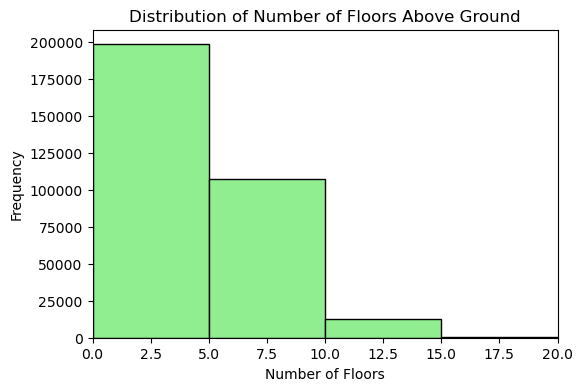

In [6]:
# Process the number of floors
def clean_floors_col(series):
    # Remove non-numeric characters and convert to float
    return pd.to_numeric(series.astype(str).str.replace(r'[^\d.]', '', regex=True), errors='coerce')

# Initialize a series for estimated floors
floors = clean_floors_col(buildings['numberOfFloorsAboveGround'])

# Impute missing values with the median number of floors
median_floors = floors.median()
if np.isnan(median_floors):
    median_floors = 3.0  # Fallback to 3 stories if dataset is too sparse
    
floors = floors.fillna(median_floors)
buildings['estimated_floors'] = floors

print(f"All buildings have assigned floors. Median is: {median_floors:.1f}")

fig, ax = plt.subplots(figsize=(6, 4))
buildings['estimated_floors'].plot(kind='hist', bins=20, ax=ax, color='lightgreen', edgecolor='black')
ax.set_title('Distribution of Number of Floors Above Ground')
ax.set_xlabel('Number of Floors')
ax.set_xlim(0, 20)  # Focus on the majority
plt.show()

## 3. Extract Floor Counts per Street Buffer

Using `geopandas.sjoin`, this logical module performs the underlying computation:
1. Buffers each given path by specific radii (e.g., 50m, 100m).
2. Intersects target spatial structures matching over these buffered regions.
3. Solves aggregate math operators (`mean`, `max`) over specific metric outputs via their unique composite group keys `fid` & `TRAM`.

In [7]:
def calculate_building_floors_in_buffer(streets_gdf, buildings_gdf, buffer_size):
    print(f"Evaluating {buffer_size}m buffers...")
    # Buffer the streets
    buffered_streets = streets_gdf.copy()
    buffered_streets['geometry'] = buffered_streets.geometry.buffer(buffer_size)
    
    # Keep only target columns for spatial join to reduce memory usage
    bldgs = buildings_gdf[['estimated_floors', 'geometry']].copy()
    
    # Spatial join: Which buildings intersect which street buffer?
    joined = gpd.sjoin(buffered_streets[['fid', 'TRAM', 'geometry']], bldgs, how='left', predicate='intersects')
    
    # If a street buffer hits nothing, it will have NaN in estimated_floors. Treatment: 0.
    joined['estimated_floors'] = joined['estimated_floors'].fillna(0)
    
    # Group by street and calculate aggregate stats
    agg_funcs = {
        'estimated_floors': ['mean', 'max']
    }
    grouped = joined.groupby(['fid', 'TRAM']).agg(agg_funcs)
    
    # Flatten MultiIndex columns
    grouped.columns = [f"catastral_bldg_floors_{col[1]}_{buffer_size}m" for col in grouped.columns]
    
    return grouped.reset_index()

features_50m = calculate_building_floors_in_buffer(noise_streets, buildings, 50)
features_100m = calculate_building_floors_in_buffer(noise_streets, buildings, 100)

display(features_50m.head())

Evaluating 50m buffers...
Evaluating 100m buffers...


,fid,TRAM,catastral_bldg_floors_mean_50m,catastral_bldg_floors_max_50m
0,0,T04719W,3.687500,9.0
1,1,T19941Z,3.132353,8.0
2,2,T18111R,4.055556,10.0
3,3,T03222Y,2.372449,10.0
4,4,T17625I,5.555556,10.0


## 4. Target Compile and Feature Merge

We enforce standard ML pipeline architecture by combining all independently sized radius runs into singular unified index records targeting both exact primary row identifiers (`fid`) and unique global segments (`TRAM`). The completed mapping outputs into `./data/processed/catastral_building_floors.csv`.

In [8]:
dataset = pd.DataFrame({
    'fid': noise_streets['fid'],
    'street_id': noise_streets['TRAM']
})

dataset = dataset.merge(features_50m, left_on=['fid', 'street_id'], right_on=['fid', 'TRAM'], how='left').drop(columns=['TRAM'], errors='ignore')
dataset = dataset.merge(features_100m, left_on=['fid', 'street_id'], right_on=['fid', 'TRAM'], how='left').drop(columns=['TRAM'], errors='ignore')

dataset = dataset.fillna(0)
display(dataset.head())

output_dir = "../../data/processed"
os.makedirs(output_dir, exist_ok=True)
dataset.to_csv(os.path.join(output_dir, "catastral_building_floors.csv"), index=False)
print("Exported catastral_building_floors.csv")

,fid,street_id,catastral_bldg_floors_mean_50m,catastral_bldg_floors_max_50m,catastral_bldg_floors_mean_100m,catastral_bldg_floors_max_100m
0,0,T04719W,3.687500,9.0,3.198502,9.0
1,1,T19941Z,3.132353,8.0,3.811224,13.0
2,2,T18111R,4.055556,10.0,3.840000,15.0
3,3,T03222Y,2.372449,10.0,2.623158,12.0
4,4,T17625I,5.555556,10.0,4.391304,16.0


Exported catastral_building_floors.csv


## 5. Output Visualization

A choropleth rendering mapping `catastral_bldg_floors_mean_50m` directly projected across geometry linestrings for qualitative checks and evaluation logic matching physical structural envelopes in Barcelona.

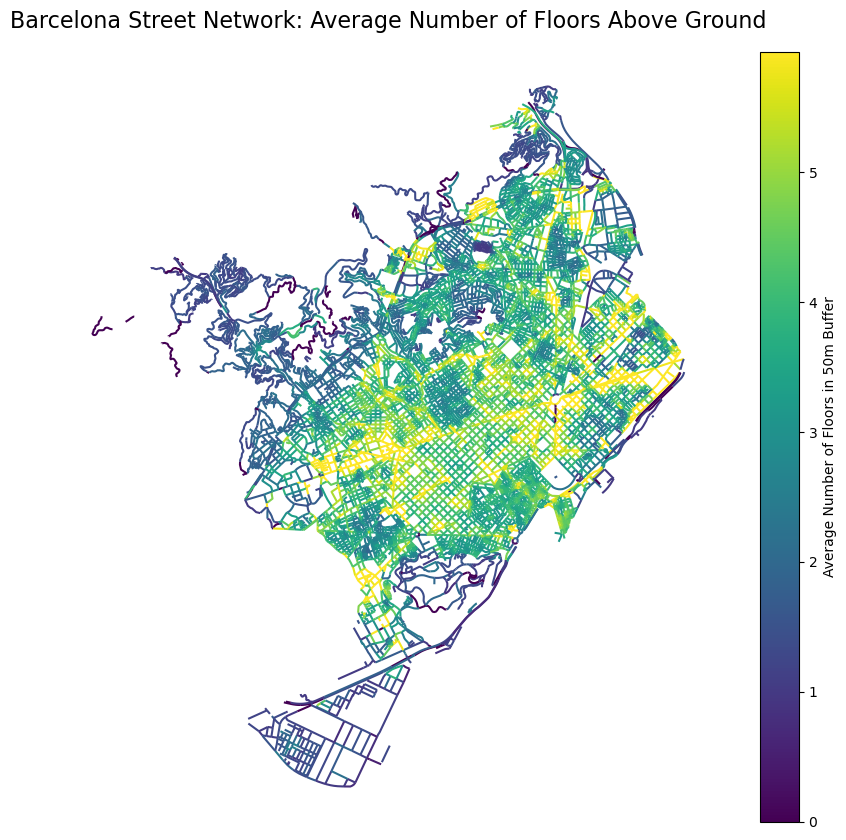

In [9]:
# Temporarily merge the result back to the street geometries for plotting
viz_gdf = noise_streets.merge(dataset[['fid', 'catastral_bldg_floors_mean_50m']], on='fid')

fig, ax = plt.subplots(figsize=(12, 10))

# Cap at 95th percentile so super tall buildings don't wash out the color map gradient
vmax_floors = viz_gdf['catastral_bldg_floors_mean_50m'].quantile(0.95)

viz_gdf.plot(
    column='catastral_bldg_floors_mean_50m',
    ax=ax,
    cmap='viridis',
    linewidth=1.5,
    legend=True,
    legend_kwds={'label': "Average Number of Floors in 50m Buffer"},
    vmax=vmax_floors
)

ax.set_title("Barcelona Street Network: Average Number of Floors Above Ground", fontsize=16)
ax.set_axis_off()
plt.show()